In [2]:
#Import libraries and loading datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, pearsonr
import seaborn as sns

In [3]:
#reading data
def read_data(name_dir):
  assessments = pd.read_csv(f"{name_dir}/assessments.csv")
  courses = pd.read_csv(f"{name_dir}courses.csv")
  studentAssessment = pd.read_csv(f"{name_dir}studentAssessment.csv")
  studentInfo = pd.read_csv(f"{name_dir}studentInfo.csv")
  studentRegistration = pd.read_csv(f"{name_dir}studentRegistration.csv")
  studentVle = pd.read_csv(f"{name_dir}studentVle.csv")
  vle = pd.read_csv(f"{name_dir}vle.csv")
  return assessments, courses, studentAssessment, studentInfo, studentRegistration, studentVle, vle

In [4]:
name_dir = "/content/data/"
assessments, courses, studentAssessment, studentInfo, studentRegistration, studentVle, vle= read_data(name_dir)

Top 10 entries of each dataset.

In [5]:
assessments.head(10)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0
5,AAA,2013J,1757,Exam,?,100.0
6,AAA,2014J,1758,TMA,19,10.0
7,AAA,2014J,1759,TMA,54,20.0
8,AAA,2014J,1760,TMA,117,20.0
9,AAA,2014J,1761,TMA,166,20.0


In [6]:
courses.head(10)

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240
5,BBB,2014B,234
6,CCC,2014J,269
7,CCC,2014B,241
8,DDD,2013J,261
9,DDD,2014J,262


In [7]:
studentAssessment.head(10)

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79
5,1752,45462,20,0,70
6,1752,45642,18,0,72
7,1752,52130,19,0,72
8,1752,53025,9,0,71
9,1752,57506,18,0,68


In [8]:
studentInfo.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,?,55<=,0,60,N,Pass


In [9]:
studentRegistration.head(10)

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?
5,AAA,2013J,38053,-110,?
6,AAA,2013J,45462,-67,?
7,AAA,2013J,45642,-29,?
8,AAA,2013J,52130,-33,?
9,AAA,2013J,53025,-179,?


In [10]:
studentVle.head(10)

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
5,AAA,2013J,28400,546652,-10,8
6,AAA,2013J,28400,546876,-10,2
7,AAA,2013J,28400,546688,-10,15
8,AAA,2013J,28400,546662,-10,17
9,AAA,2013J,28400,546890,-10,1


In [11]:
vle.head(10)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?
5,546614,AAA,2013J,homepage,?,?
6,546897,AAA,2013J,url,?,?
7,546678,AAA,2013J,oucontent,?,?
8,546933,AAA,2013J,resource,?,?
9,546708,AAA,2013J,oucontent,?,?


### Merging and Cleaning the data


We want student data so  we will use StudentRegisteration to gain extra information.

In [12]:
#merging data with studentInfo
studentdata = pd.merge(studentRegistration, studentInfo, on=['id_student', 'code_module', 'code_presentation'], how='inner')

In [13]:
#Merging data with courses
studentdata = pd.merge(studentdata, courses, on=['code_module', 'code_presentation'], how='inner')

In [14]:
studentdata

,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length
0,AAA,2013J,11391,-159,?,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
1,AAA,2013J,28400,-53,?,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268
2,AAA,2013J,30268,-92,12,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268
3,AAA,2013J,31604,-52,?,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268
4,AAA,2013J,32885,-176,?,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,-4,?,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,269
32589,GGG,2014J,2645731,-23,?,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,269
32590,GGG,2014J,2648187,-129,?,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,269
32591,GGG,2014J,2679821,-49,101,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,269


In [15]:
studentAssessment.shape


(173912, 5)

In [16]:
assessments.shape

(206, 6)

In [17]:
#merging student assesment and assesment data
student_assesment_data = assessments.merge(studentAssessment,on=['id_assessment'],how="inner")

In [18]:
student_assesment_data

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
0,AAA,2013J,1752,TMA,19,10.0,11391,18,0,78
1,AAA,2013J,1752,TMA,19,10.0,28400,22,0,70
2,AAA,2013J,1752,TMA,19,10.0,31604,17,0,72
3,AAA,2013J,1752,TMA,19,10.0,32885,26,0,69
4,AAA,2013J,1752,TMA,19,10.0,38053,19,0,79
...,...,...,...,...,...,...,...,...,...,...
173907,GGG,2014J,37437,TMA,173,0.0,652462,172,0,60
173908,GGG,2014J,37437,TMA,173,0.0,652539,176,0,75
173909,GGG,2014J,37437,TMA,173,0.0,653157,187,0,70
173910,GGG,2014J,37437,TMA,173,0.0,653252,171,0,70


In [19]:
student_assesment_data.replace('?', np.nan, inplace=True)

In [20]:
student_assesment_data.isna().sum()

,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,2865
weight,0
id_student,0
date_submitted,0
is_banked,0
score,173


In [21]:
# We are dropping the nulls value in date column
student_assesment_data["score"].fillna(0, inplace=True)
student_assesment_data.dropna(inplace=True)

<ipython-input-21-71e945c3f393>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_assesment_data["score"].fillna(0, inplace=True)


In [22]:
#checking null values in student assesment data
student_assesment_data.isna().sum()

,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,0
weight,0
id_student,0
date_submitted,0
is_banked,0
score,0


In [23]:
student_data_final = student_assesment_data.merge(studentdata,on=['code_module','code_presentation','id_student'],how="inner")

In [24]:
student_data_final

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,...,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length
0,AAA,2013J,1752,TMA,19,10.0,11391,18,0,78,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
1,AAA,2013J,1752,TMA,19,10.0,28400,22,0,70,...,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268
2,AAA,2013J,1752,TMA,19,10.0,31604,17,0,72,...,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268
3,AAA,2013J,1752,TMA,19,10.0,32885,26,0,69,...,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268
4,AAA,2013J,1752,TMA,19,10.0,38053,19,0,79,...,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171042,GGG,2014J,37437,TMA,173,0.0,652462,172,0,60,...,M,South Region,Lower Than A Level,90-100%,35-55,0,30,N,Pass,269
171043,GGG,2014J,37437,TMA,173,0.0,652539,176,0,75,...,F,South Region,A Level or Equivalent,70-80%,0-35,0,30,N,Pass,269
171044,GGG,2014J,37437,TMA,173,0.0,653157,187,0,70,...,F,West Midlands Region,Lower Than A Level,20-30%,0-35,0,30,N,Pass,269
171045,GGG,2014J,37437,TMA,173,0.0,653252,171,0,70,...,F,East Anglian Region,No Formal quals,20-30%,0-35,0,30,Y,Pass,269


In [25]:
student_data_final['code_presentation'].unique()

array(['2013J', '2014J', '2013B', '2014B'], dtype=object)

In [26]:
# Replacing the ? into Nan type
student_data_final.replace('?', np.nan, inplace=True)


In [27]:
#checking null values in final dataset.
student_data_final.isna().sum()

,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,0
weight,0
id_student,0
date_submitted,0
is_banked,0
score,0


In [28]:
# We will fill the missing values by taking the mode
regions_list = student_data_final[student_data_final['imd_band'].isnull()]['region'].unique()

for region in regions_list:
  mode_imd_band = student_data_final[student_data_final['region'] == region]['imd_band'].mode()[0]
  student_data_final.loc[(student_data_final['imd_band'].isnull()) & (student_data_final['region'] == region), 'imd_band'] = mode_imd_band

In [29]:
# date_unregistration is null when student doesn't complete his study, so finished-unfinished labels are assigned instead of date_registration
# if the final result is (Pass,fail,Distinction) a 'Finished' label is applied or else 'Unfinished'.


student_data_final['study_status'] = np.where(student_data_final['final_result'].isin(['Pass', 'Fail', 'Distinction']), 'finished', 'unfinished')

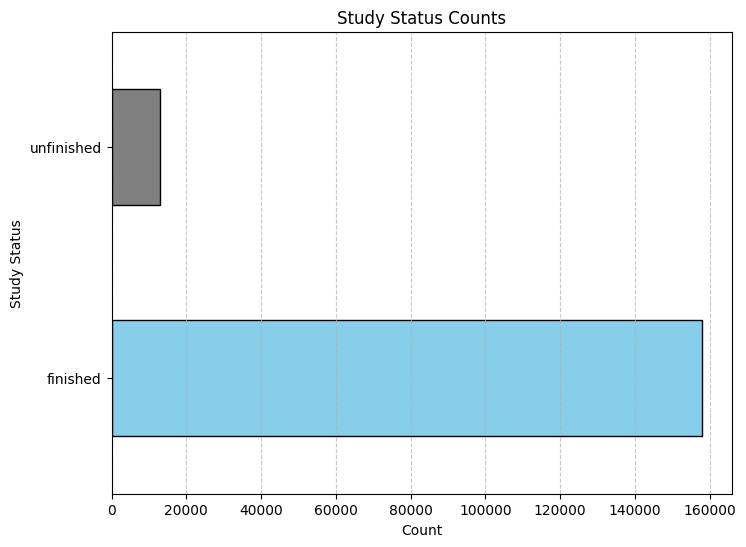

In [30]:
study_status_counts = student_data_final['study_status'].value_counts()

# Plot a bar graph
plt.figure(figsize=(8, 6))
study_status_counts.plot(kind='barh', color=['skyblue', 'grey'], edgecolor='black')
plt.title('Study Status Counts')
plt.xlabel('Count')
plt.ylabel('Study Status')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [31]:
student_data_final['date_unregistration'] = pd.to_numeric(student_data_final['date_unregistration'], errors='coerce')
student_data_final['score'] = pd.to_numeric(student_data_final['score'], errors='coerce')
student_data_final['date'] = pd.to_numeric(student_data_final['score'], errors='coerce')
student_data_final['date_submitted'] = pd.to_numeric(student_data_final['score'], errors='coerce')
student_data_final['date_registration'] = pd.to_numeric(student_data_final['score'], errors='coerce')

def categorize_withdrawal(Date):
    if pd.isnull(Date):
        return "didn't withdraw"
    elif Date < 0:
        return 'early withdrawal'
    elif Date >=0 and Date < 70:
        return 'normal withdrawal'
    else:
        return 'late withdrawal'

student_data_final['withdrawal_status'] = student_data_final['date_unregistration'].apply(categorize_withdrawal)

student_data_final[['date_unregistration', 'withdrawal_status']].head()

,date_unregistration,withdrawal_status
0,NaN,didn't withdraw
1,NaN,didn't withdraw
2,NaN,didn't withdraw
3,NaN,didn't withdraw
4,NaN,didn't withdraw


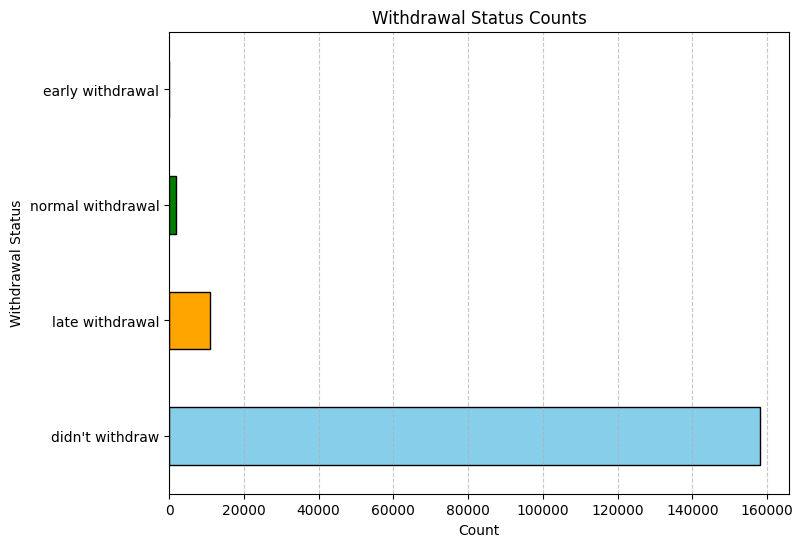

In [32]:
status_counts = student_data_final['withdrawal_status'].value_counts()

# Plot a  bar graph
plt.figure(figsize=(8, 6))
status_counts.plot(kind='barh', color=['skyblue', 'orange', 'green', 'red'], edgecolor='black')
plt.title('Withdrawal Status Counts')
plt.xlabel('Count')
plt.ylabel('Withdrawal Status')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [33]:
# Dropping the date_unregistration column as we have extracted all the necessary information from it
student_data_final.drop(['date_unregistration'],axis=1,inplace=True)

In [34]:
# Dropping the date_registration column as it only has 7 records
student_data_final.dropna(inplace=True)

In [35]:
student_data_final.isna().sum()

,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,0
weight,0
id_student,0
date_submitted,0
is_banked,0
score,0


In [36]:
studentVle.shape

(10655280, 6)

In [37]:
vle.shape

(6364, 6)

In [38]:
# Now we will merge the StudentVLE data with the VLE data as we have done previously.
# This is because each student interaction with onine learning materials is paired with the corresponding material details from VLE.

studentInteraction = studentVle.merge(vle,on=['code_module','code_presentation','id_site'],how="inner")

In [39]:
studentInteraction

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,forumng,?,?
1,AAA,2013J,28400,546652,-10,1,forumng,?,?
2,AAA,2013J,28400,546652,-10,1,forumng,?,?
3,AAA,2013J,28400,546614,-10,11,homepage,?,?
4,AAA,2013J,28400,546714,-10,1,oucontent,?,?
...,...,...,...,...,...,...,...,...,...
10655275,GGG,2014J,675811,896943,269,3,homepage,?,?
10655276,GGG,2014J,675578,896943,269,1,homepage,?,?
10655277,GGG,2014J,654064,896943,269,3,homepage,?,?
10655278,GGG,2014J,654064,896939,269,1,forumng,?,?


In [40]:
# we only need the Sum_Click for each Student Id, we can drop the date, week_from, week_to as they contain to many null values
# doesn't provide much information for feature engineering

grouped_studentInteraction = studentInteraction.groupby(
    ['id_student', 'code_module', 'code_presentation','activity_type'], as_index=False)["sum_click"].agg(['sum', 'count'])

In [41]:
# Now we will merge the student_data_final and grouped_studentInteraction to make our final dataframe

df_final = grouped_studentInteraction.merge(student_data_final,on=['id_student', 'code_module', 'code_presentation'],how='inner')

In [42]:
df_final

,id_student,code_module,code_presentation,activity_type,sum,count,id_assessment,assessment_type,date,weight,...,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length,study_status,withdrawal_status
0,6516,AAA,2014J,dataplus,21,4,1758,TMA,60,10.0,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
1,6516,AAA,2014J,dataplus,21,4,1759,TMA,48,20.0,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
2,6516,AAA,2014J,dataplus,21,4,1760,TMA,63,20.0,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
3,6516,AAA,2014J,dataplus,21,4,1761,TMA,61,20.0,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
4,6516,AAA,2014J,dataplus,21,4,1762,TMA,77,30.0,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580028,2698588,BBB,2014J,url,2,2,15020,TMA,100,0.0,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1580029,2698588,BBB,2014J,url,2,2,15021,TMA,85,10.0,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1580030,2698588,BBB,2014J,url,2,2,15022,TMA,87,20.0,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1580031,2698588,BBB,2014J,url,2,2,15023,TMA,95,35.0,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw


In [43]:
df_final.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id_student,1580033.0,709064.860299,557298.678692,6516.0,504819.0,584433.0,634999.0,2698588.0
sum,1580033.0,213.237613,467.771762,1.0,11.0,48.0,203.0,13154.0
count,1580033.0,55.618683,85.524957,1.0,7.0,25.0,68.0,1727.0
id_assessment,1580033.0,27805.917329,8495.049554,1752.0,24289.0,30717.0,34887.0,37443.0
date,1580033.0,76.478259,18.138992,0.0,67.0,80.0,90.0,100.0
weight,1580033.0,11.325734,14.101814,0.0,0.0,9.0,18.0,100.0
date_submitted,1580033.0,76.478259,18.138992,0.0,67.0,80.0,90.0,100.0
is_banked,1580033.0,0.007222,0.084675,0.0,0.0,0.0,0.0,1.0
score,1580033.0,76.478259,18.138992,0.0,67.0,80.0,90.0,100.0
date_registration,1580033.0,76.478259,18.138992,0.0,67.0,80.0,90.0,100.0


## Feature Engineering

In [44]:
# 1. Assessment Engagement Scor
# Captures interaction intensity with VLE by multiplying the number of clicks (sum) with the count of activities.
df_final['assessment_engagement_score'] = df_final['sum'] * df_final['count']

# 2. Module Engagement Rate
# Provides a normalized engagement metric by dividing the total number of clicks by the module presentation length.
df_final['module_engagement_rate'] = df_final['sum'] / df_final['module_presentation_length']

# 3. Cumulative Score
# Tracks overall performance progression by calculating the cumulative sum of scores for each student.
df_final['cumulative_score'] = df_final.groupby('id_student')['score'].cumsum()

# 4. Activity Diversity
# Measures how varied a student’s engagement is by counting the unique activity types they interacted with.
df_final['activity_diversity'] = df_final.groupby('id_student')['activity_type'].transform('nunique')

In [45]:
# Drop the 'count' column as it is used in the calculation of 'assessment_engagement_score'
df_final = df_final.drop(columns=['count'], axis=1)  # Redundant after 'assessment_engagement_score' is calculated

# Drop the 'sum' column since it is used in calculating 'assessment_engagement_score' and 'module_engagement_rate'
df_final = df_final.drop(columns=['sum'], axis=1)  # Redundant after 'assessment_engagement_score' and 'module_engagement_rate' are calculated

# Drop the 'weight' column as it is included in the 'weighted_engagement' feature
df_final = df_final.drop(columns=['weight'], axis=1)  # Redundant after 'weighted_engagement' is calculated

# Drop the 'activity_type' column as 'activity_diversity' already captures the diversity of activities
df_final = df_final.drop(columns=['activity_type'], axis=1)  # Redundant after 'activity_diversity' is calculated

In [46]:
# we found some duplicate values so we removed from the data set

df_final = df_final.drop_duplicates()

###Final Data after Cleaning, EDA and Feature Engineering

In [47]:
df_final

,id_student,code_module,code_presentation,id_assessment,assessment_type,date,date_submitted,is_banked,score,date_registration,...,studied_credits,disability,final_result,module_presentation_length,study_status,withdrawal_status,assessment_engagement_score,module_engagement_rate,cumulative_score,activity_diversity
0,6516,AAA,2014J,1758,TMA,60,60,0,60,60,...,60,N,Pass,269,finished,didn't withdraw,84,0.078067,60,7
1,6516,AAA,2014J,1759,TMA,48,48,0,48,48,...,60,N,Pass,269,finished,didn't withdraw,84,0.078067,108,7
2,6516,AAA,2014J,1760,TMA,63,63,0,63,63,...,60,N,Pass,269,finished,didn't withdraw,84,0.078067,171,7
3,6516,AAA,2014J,1761,TMA,61,61,0,61,61,...,60,N,Pass,269,finished,didn't withdraw,84,0.078067,232,7
4,6516,AAA,2014J,1762,TMA,77,77,0,77,77,...,60,N,Pass,269,finished,didn't withdraw,84,0.078067,309,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580028,2698588,BBB,2014J,15020,TMA,100,100,0,100,100,...,120,N,Distinction,262,finished,didn't withdraw,4,0.007634,2872,7
1580029,2698588,BBB,2014J,15021,TMA,85,85,0,85,85,...,120,N,Distinction,262,finished,didn't withdraw,4,0.007634,2957,7
1580030,2698588,BBB,2014J,15022,TMA,87,87,0,87,87,...,120,N,Distinction,262,finished,didn't withdraw,4,0.007634,3044,7
1580031,2698588,BBB,2014J,15023,TMA,95,95,0,95,95,...,120,N,Distinction,262,finished,didn't withdraw,4,0.007634,3139,7


In [48]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1580024 entries, 0 to 1580032
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id_student                   1580024 non-null  int64  
 1   code_module                  1580024 non-null  object 
 2   code_presentation            1580024 non-null  object 
 3   id_assessment                1580024 non-null  int64  
 4   assessment_type              1580024 non-null  object 
 5   date                         1580024 non-null  int64  
 6   date_submitted               1580024 non-null  int64  
 7   is_banked                    1580024 non-null  int64  
 8   score                        1580024 non-null  int64  
 9   date_registration            1580024 non-null  int64  
 10  gender                       1580024 non-null  object 
 11  region                       1580024 non-null  object 
 12  highest_education            1580024 non-null  

In [49]:
df_final.isna().sum()

,0
id_student,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,0
date_submitted,0
is_banked,0
score,0
date_registration,0


In [50]:
# This will create only three types of highest_education 'HE Qualification', 'Lower Than A Level', 'A Level or Equivalent'

df_final['highest_education'] = np.where( (df_final['highest_education'] == 'No Formal quals'),'Lower Than A Level',df_final['highest_education'])


# Rename post-grads
df_final['highest_education'] = np.where( (df_final['highest_education'] == 'Post Graduate Qualification'),'HE Qualification',df_final['highest_education'])

In [51]:
# This will create only two age_bands 0-35 and 35+

df_final['age_band'] = np.where( (df_final['age_band'] == '55<='), '35+', df_final['age_band'])

df_final['age_band'] = np.where( (df_final['age_band'] == '35-55'),'35+',df_final['age_band'])

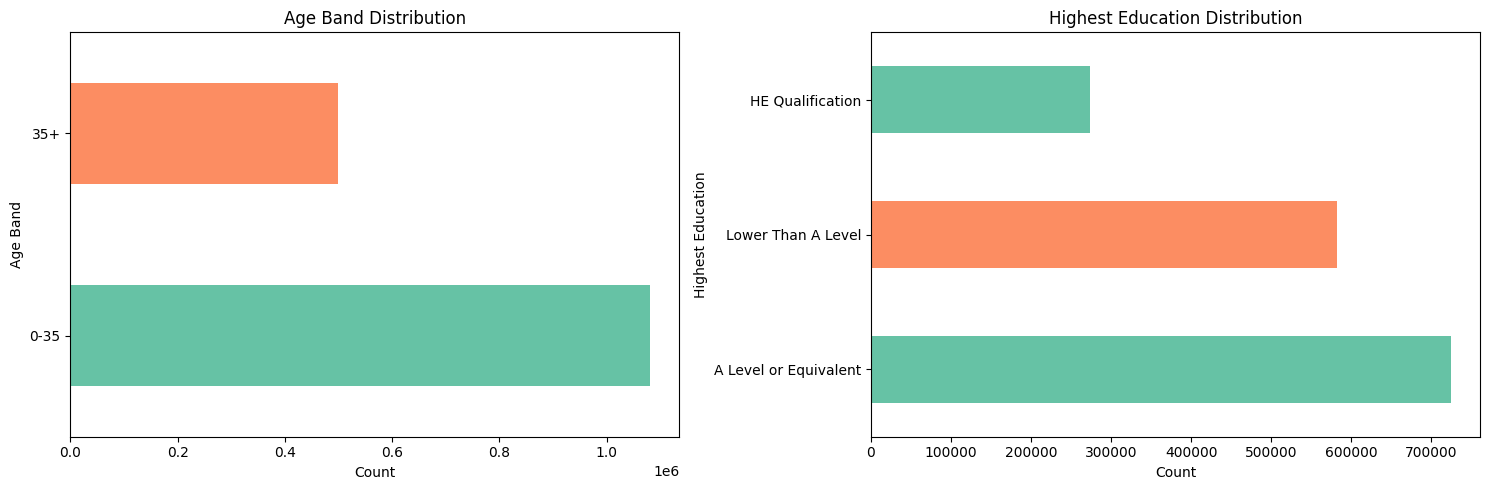

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = sns.color_palette("Set2", len(df_final['age_band'].value_counts()))

# Horizontal bar chart for 'age_band'
df_final['age_band'].value_counts().plot(kind='barh', ax=axes[0], color=palette)
axes[0].set_title('Age Band Distribution')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Age Band')

# Horizontal bar chart for 'highest_education'
df_final['highest_education'].value_counts().plot(kind='barh', ax=axes[1], color=palette)
axes[1].set_title('Highest Education Distribution')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Highest Education')

plt.tight_layout()
plt.show()

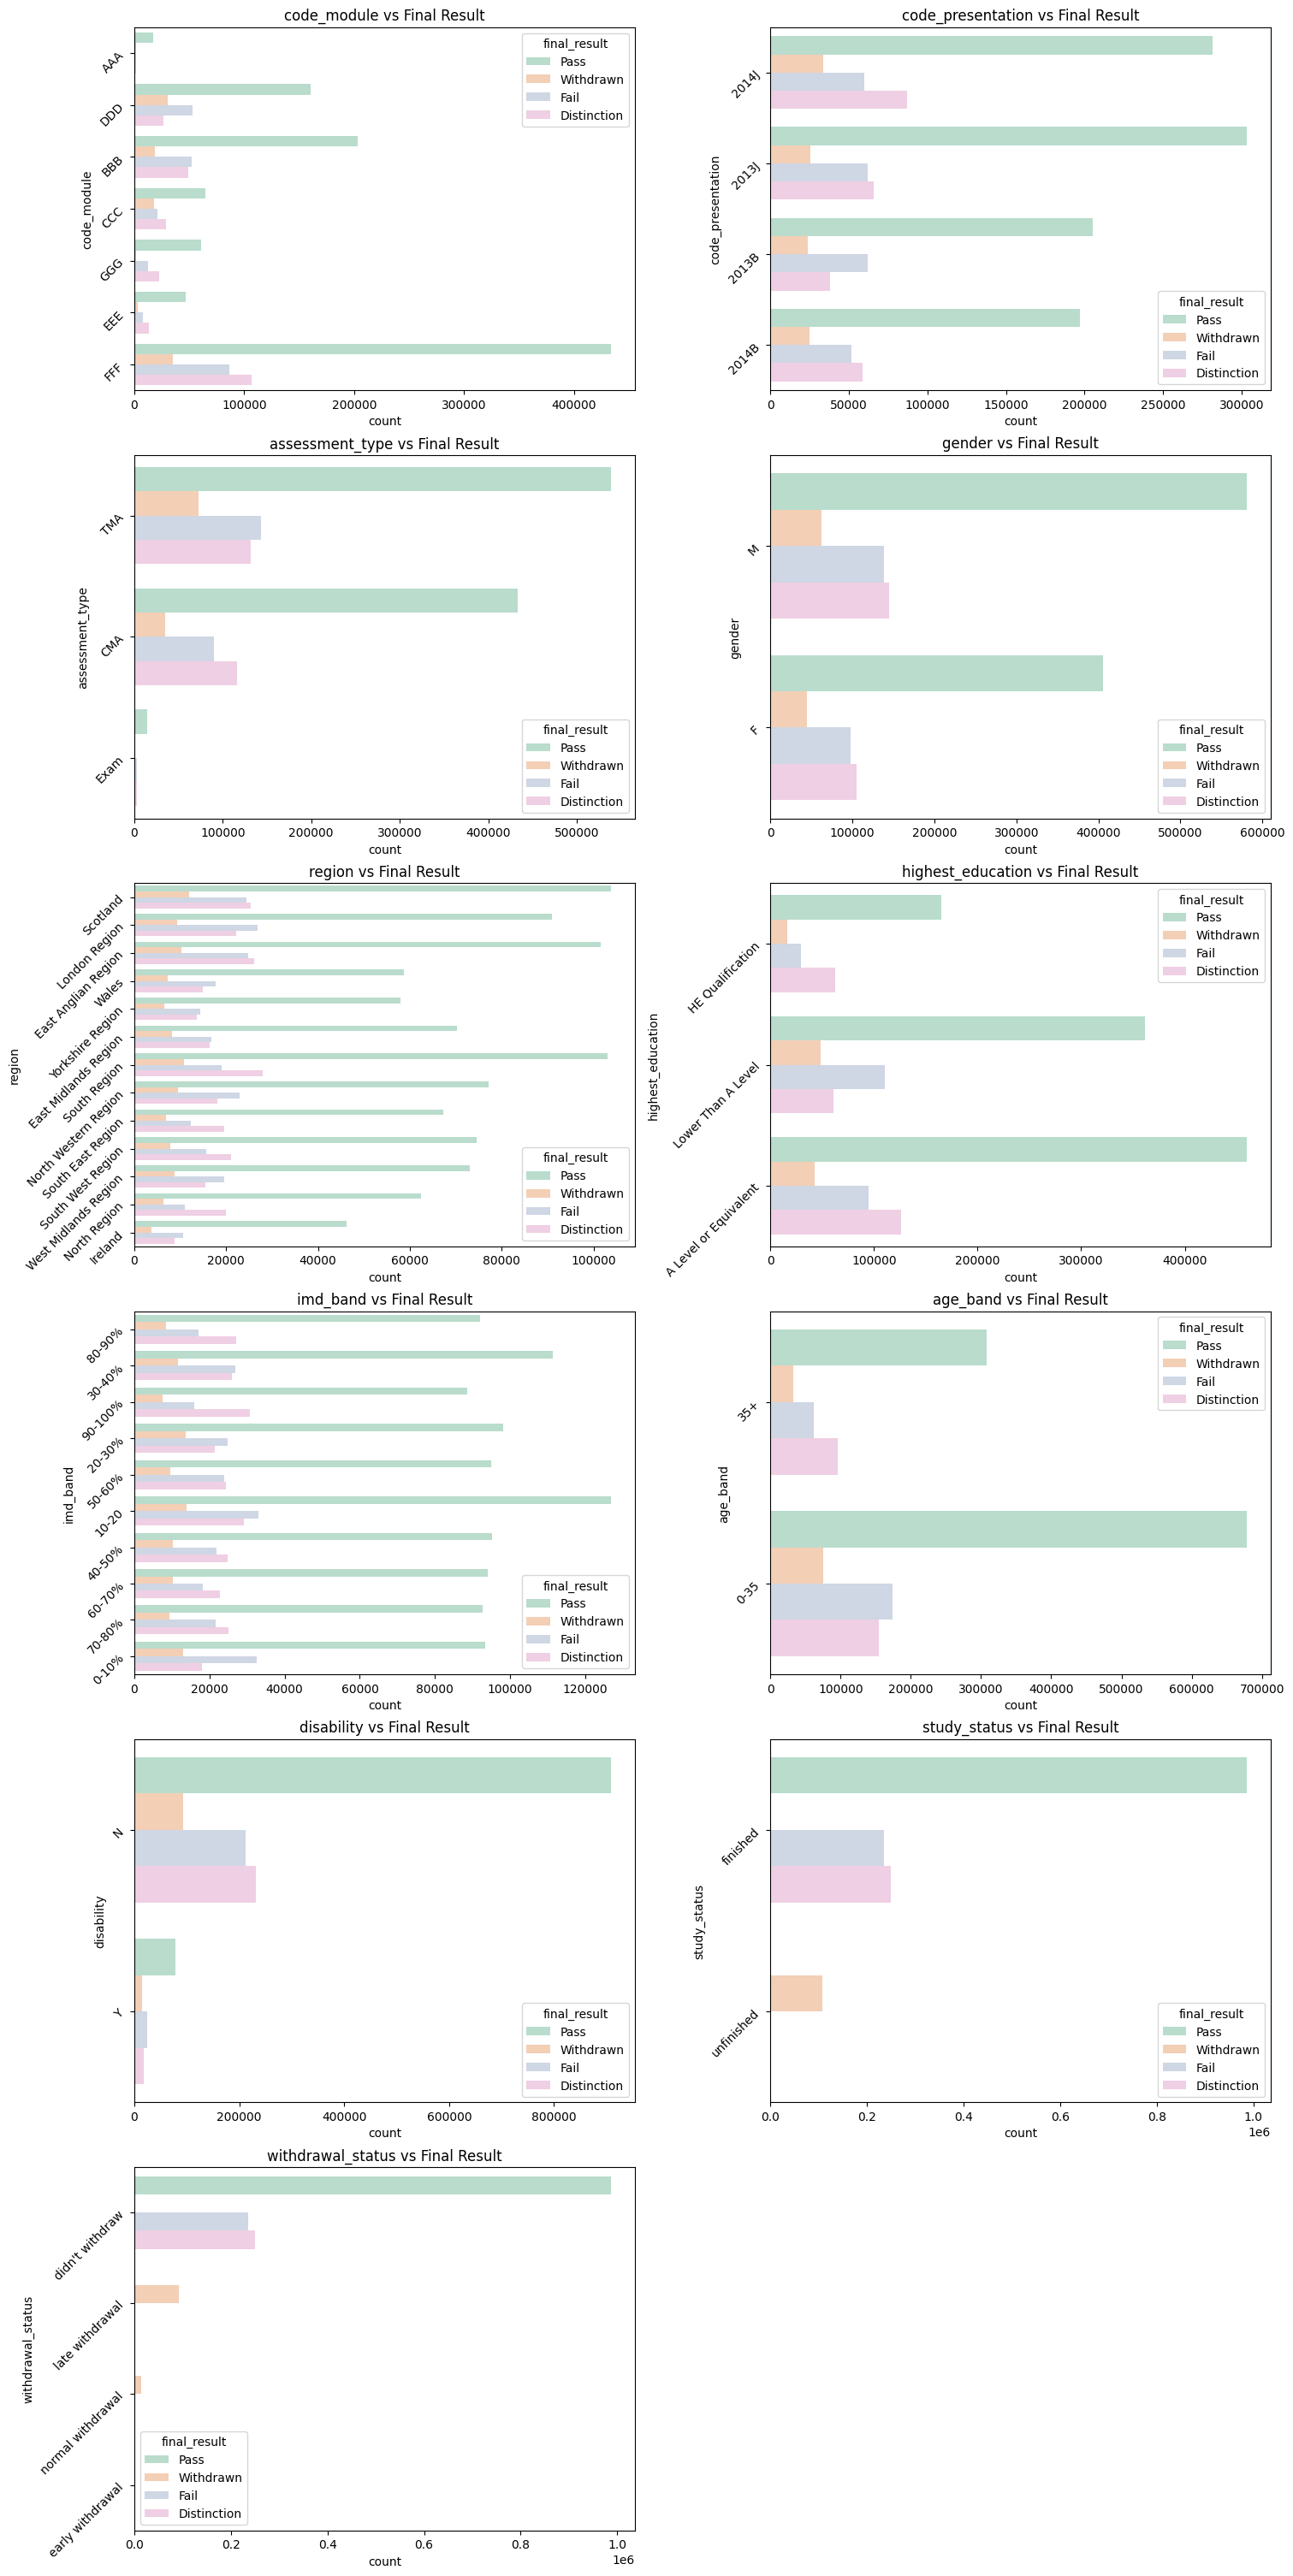

In [53]:
categorical_cols = df_final.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('final_result')

num_cols = 2  # Number of columns in the grid
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(y=col, hue='final_result', data=df_final, ax=axes[i], palette="Pastel2")
    axes[i].set_title(f'{col} vs Final Result')
    axes[i].tick_params(axis='y', rotation=45)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.show()


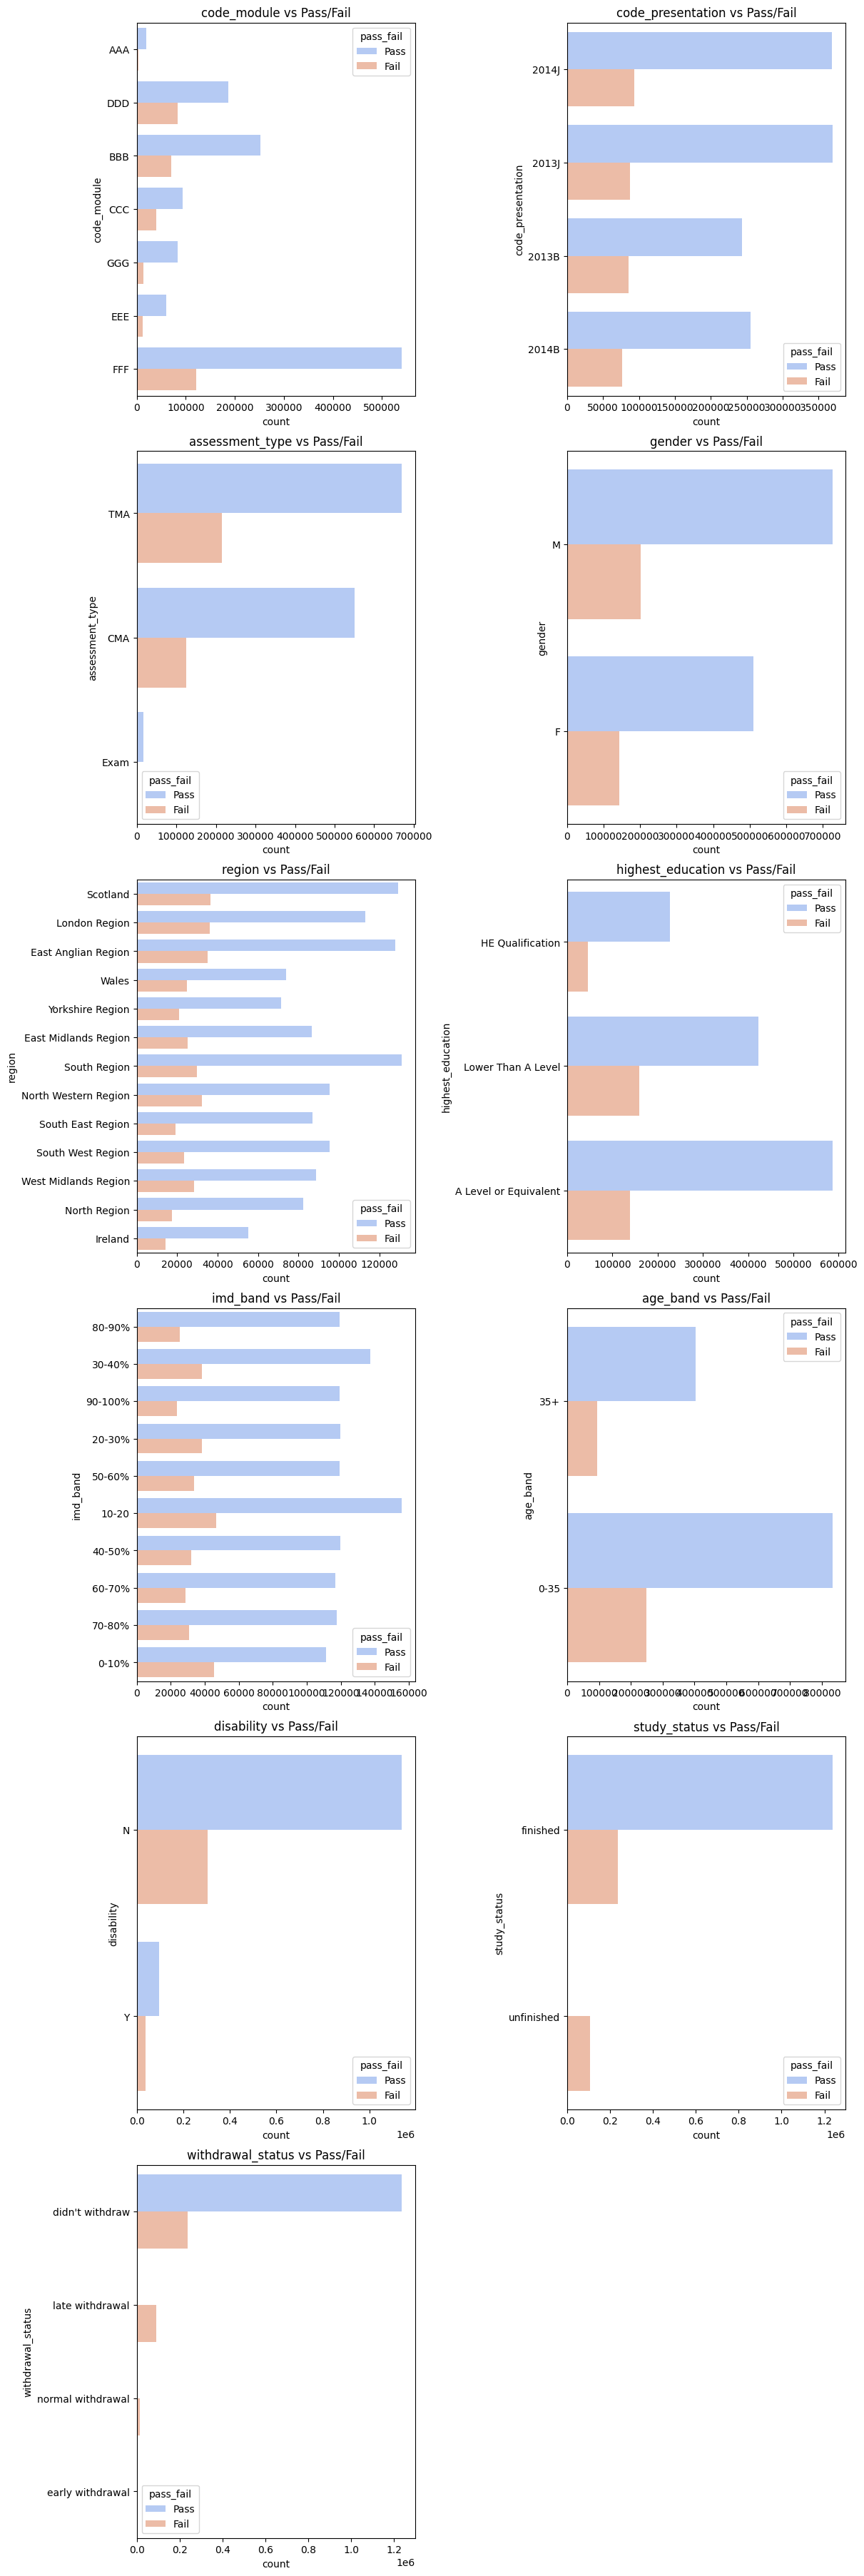

In [54]:
df_final['pass_fail'] = df_final['final_result'].apply(lambda x: 'Pass' if x in ['Pass', 'Distinction'] else 'Fail')

# Investigate the relationship between pass_fail and different categorical features
categorical_cols = df_final.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop(['final_result', 'pass_fail'])

num_cols = 2  # Number of columns in the grid (2 per row)
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6 * num_rows), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(y=col, hue='pass_fail', data=df_final, ax=axes[i], palette="coolwarm")  # Horizontal orientation
    axes[i].set_title(f'{col} vs Pass/Fail', fontsize=12)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].tick_params(axis='x', labelsize=10)

# Remove unused axes
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.show()
df_final.drop(['pass_fail'], axis=1, inplace=True)


<ipython-input-55-9cf27cd38862>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_modules_chosen.values, y=top_modules_chosen.index, palette='coolwarm')


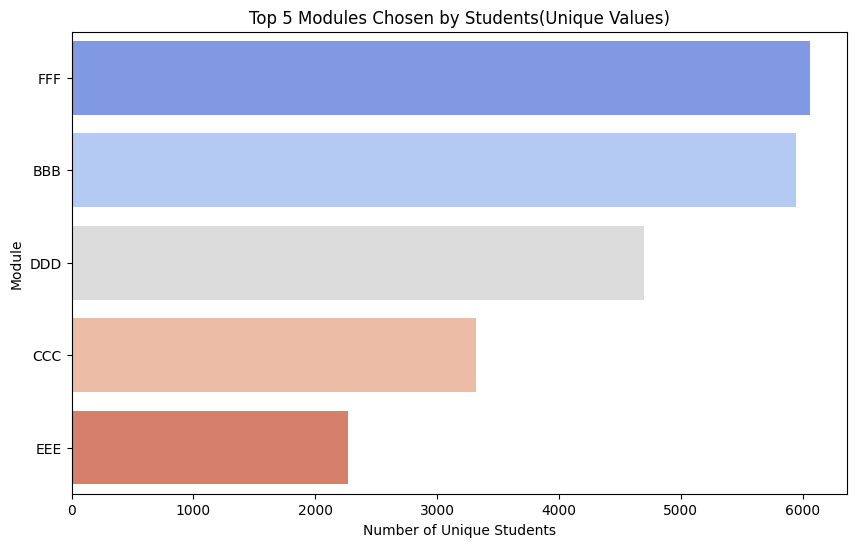


Number of unique students per module:
code_module
FFF    6057
BBB    5943
DDD    4695
CCC    3318
EEE    2268
Name: id_student, dtype: int64


In [55]:
# Count the unique number of students per module
unique_student_counts = df_final.groupby('code_module')['id_student'].nunique()

# Sort and select the top 5 modules with the most unique students
top_modules_chosen = unique_student_counts.sort_values(ascending=False).head(5)

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=top_modules_chosen.values, y=top_modules_chosen.index, palette='coolwarm')
plt.title('Top 5 Modules Chosen by Students(Unique Values)')
plt.xlabel('Number of Unique Students')
plt.ylabel('Module')
plt.show()

# Display the counts for each module
print("\nNumber of unique students per module:")
print(top_modules_chosen)


<ipython-input-56-789d44926976>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_avg_score_per_module.values, y=unique_avg_score_per_module.index, palette='Reds')


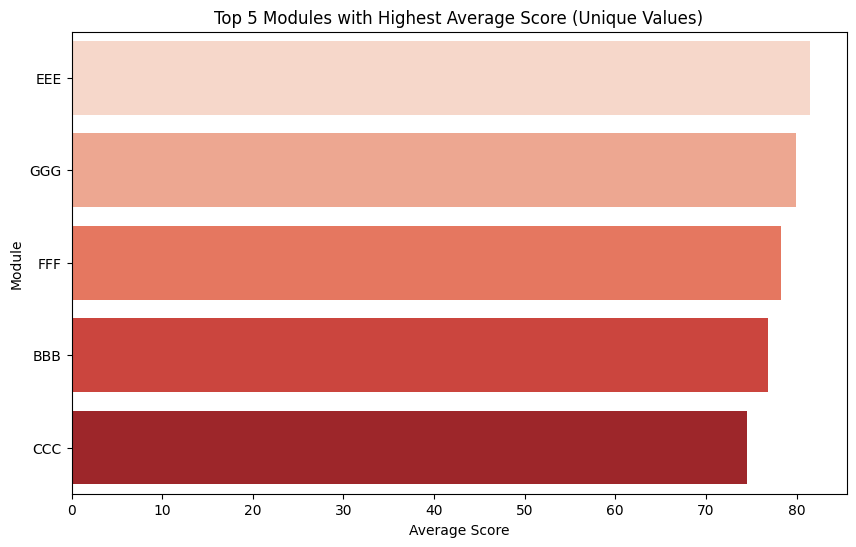

code_module
EEE    81.441304
GGG    79.942976
FFF    78.300051
BBB    76.810892
CCC    74.522153
Name: score, dtype: float64


In [56]:
# Calculate the average score per unique student in each module
unique_avg_score_per_module = df_final.groupby('code_module')['score'].mean().sort_values(ascending=False).head(5)

# Plotting bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_avg_score_per_module.values, y=unique_avg_score_per_module.index, palette='Reds')
plt.title('Top 5 Modules with Highest Average Score (Unique Values)')
plt.xlabel('Average Score')
plt.ylabel('Module')
plt.show()

print(unique_avg_score_per_module)

<ipython-input-57-09664c1ff77e>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_avg_score_per_module.values, y=unique_avg_score_per_module.index, palette='Greens')


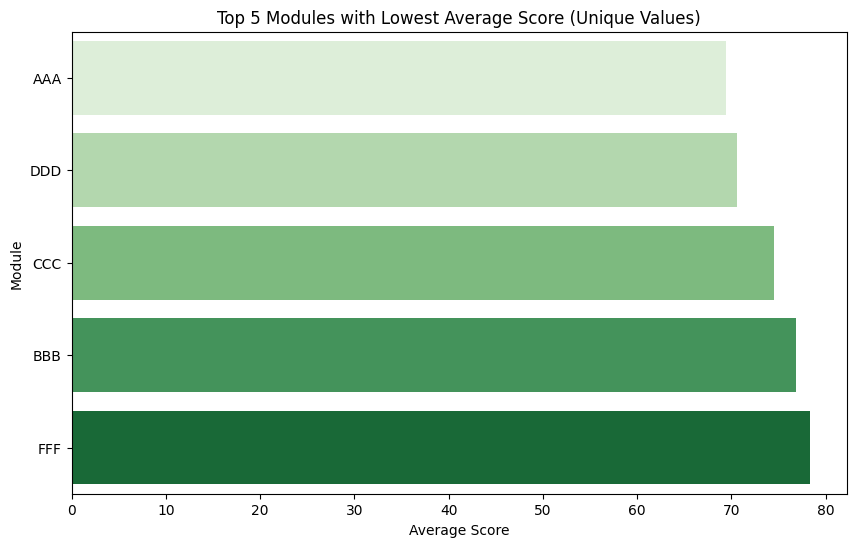

code_module
AAA    69.441568
DDD    70.597105
CCC    74.522153
BBB    76.810892
FFF    78.300051
Name: score, dtype: float64


In [57]:
# Calculate the average score per unique student in each module
unique_avg_score_per_module = (
    df_final.groupby('code_module')['score'].mean()  # Calculate average score for each unique student in each module
    .sort_values(ascending=True)  # Sort by lowest average score
    .head(5)  # Select top 5 modules with lowest average score
)

# Plot the bar graph horizontally
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_avg_score_per_module.values, y=unique_avg_score_per_module.index, palette='Greens')
plt.title('Top 5 Modules with Lowest Average Score (Unique Values)')
plt.ylabel('Module')
plt.xlabel('Average Score')
plt.show()

print(unique_avg_score_per_module)

<ipython-input-58-6fb08b0ca8b5>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fail_count_per_module.values, y=top_fail_count_per_module.index, palette='coolwarm')


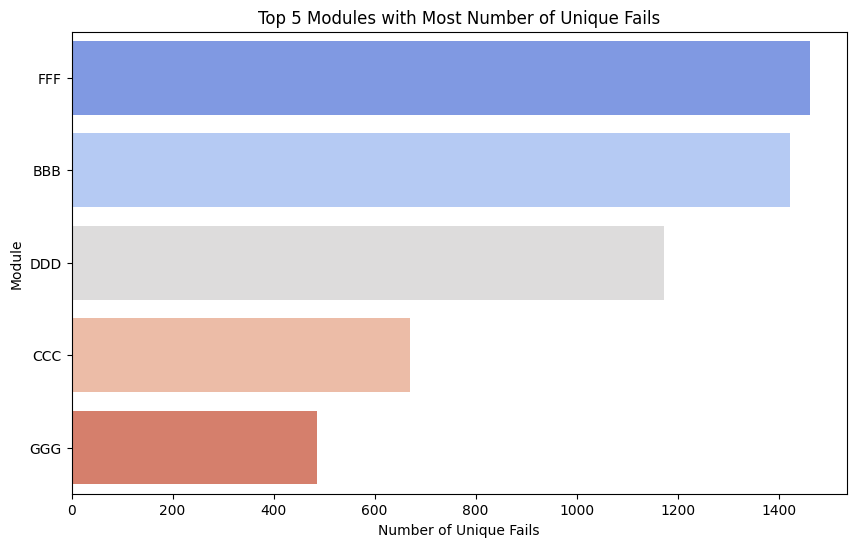


Number of unique fails per module:
code_module
FFF    1461
BBB    1423
DDD    1173
CCC     670
GGG     485
Name: id_student, dtype: int64


In [58]:
# Filter data for students who fail criteria
fail_data = df_final[df_final['final_result'] == 'Fail']

# Count the unique number of students who failed in each module
fail_count_per_module = fail_data.groupby('code_module')['id_student'].nunique()

# Sort and select the top 5 modules with the most number of unique fails
top_fail_count_per_module = fail_count_per_module.sort_values(ascending=False).head(5)

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=top_fail_count_per_module.values, y=top_fail_count_per_module.index, palette='coolwarm')
plt.title('Top 5 Modules with Most Number of Unique Fails')
plt.xlabel('Number of Unique Fails')
plt.ylabel('Module')
plt.show()

print("\nNumber of unique fails per module:")
print(top_fail_count_per_module)

<ipython-input-59-92f1fef2ec5b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, y='age_band', palette='Set3')


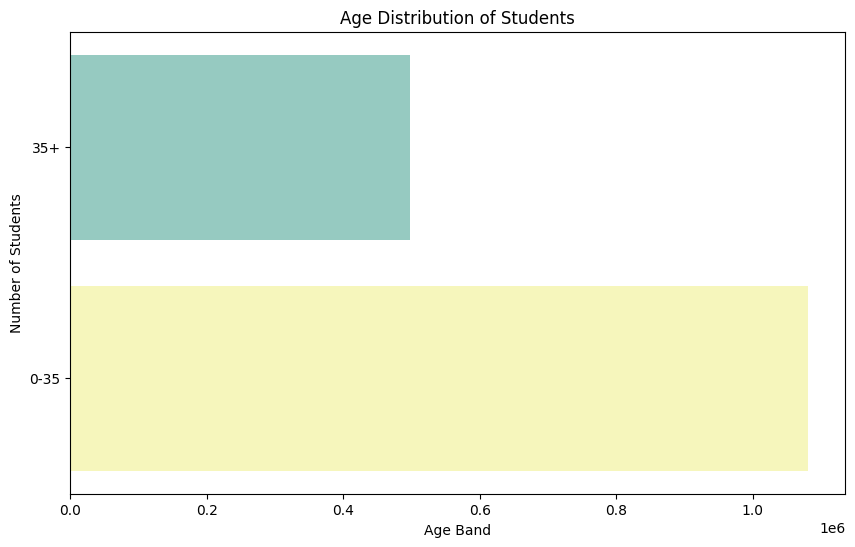

In [59]:
# Plot the distribution of age bands
plt.figure(figsize=(10,6))
sns.countplot(data=df_final, y='age_band', palette='Set3')
plt.title('Age Distribution of Students')
plt.xlabel('Age Band')
plt.ylabel('Number of Students')
plt.show()


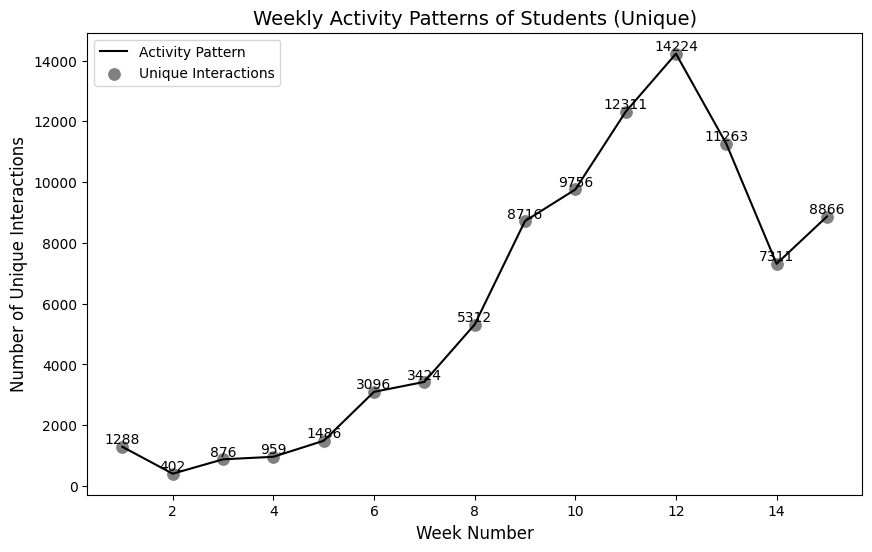

In [60]:
# Convert 'date' (number of days) into week number
df_final['week_number'] = (df_final['date'] // 7) + 1  # Adding 1 to start from Week 1

# Count unique students interacting in each week
weekly_activity = df_final.groupby('week_number')['id_student'].nunique()

# Plotting weekly activity pattern with line and scatter plot
plt.figure(figsize=(10, 6))

# Line plot
sns.lineplot(x=weekly_activity.index, y=weekly_activity.values, color='black', label='Activity Pattern')

# Scatter plot
sns.scatterplot(x=weekly_activity.index, y=weekly_activity.values, s=100, color='grey', label='Unique Interactions')

# Add titles and labels
plt.title('Weekly Activity Patterns of Students (Unique)', fontsize=14)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Number of Unique Interactions', fontsize=12)

# Annotate each point with the count value
for x, y in zip(weekly_activity.index, weekly_activity.values):
    plt.text(x, y, f'{y}', color='black', ha="center", va="bottom", fontsize=10)

plt.legend()
plt.show()



## Hypothesis Testing

In [61]:
X= ['assessment_engagement_score','module_engagement_rate', 'activity_diversity']
Y= ['cumulative_score']

# Calculate correlation between selected features and cumulative_score
correlations = {}
for col in X:  # Exclude 'cumulative_score' as it is the dependent variable
    corr, p_value = pearsonr(df_final[col], df_final['cumulative_score'])
    correlations[col] = {'Correlation': corr, 'p-value': p_value}

# Print the correlation results
print("Correlation Analysis Results:")
for feature, values in correlations.items():
    print(f"{feature}: Correlation = {values['Correlation']:.4f}")

Correlation Analysis Results:
assessment_engagement_score: Correlation = 0.0154
module_engagement_rate: Correlation = 0.0660
activity_diversity: Correlation = 0.5237


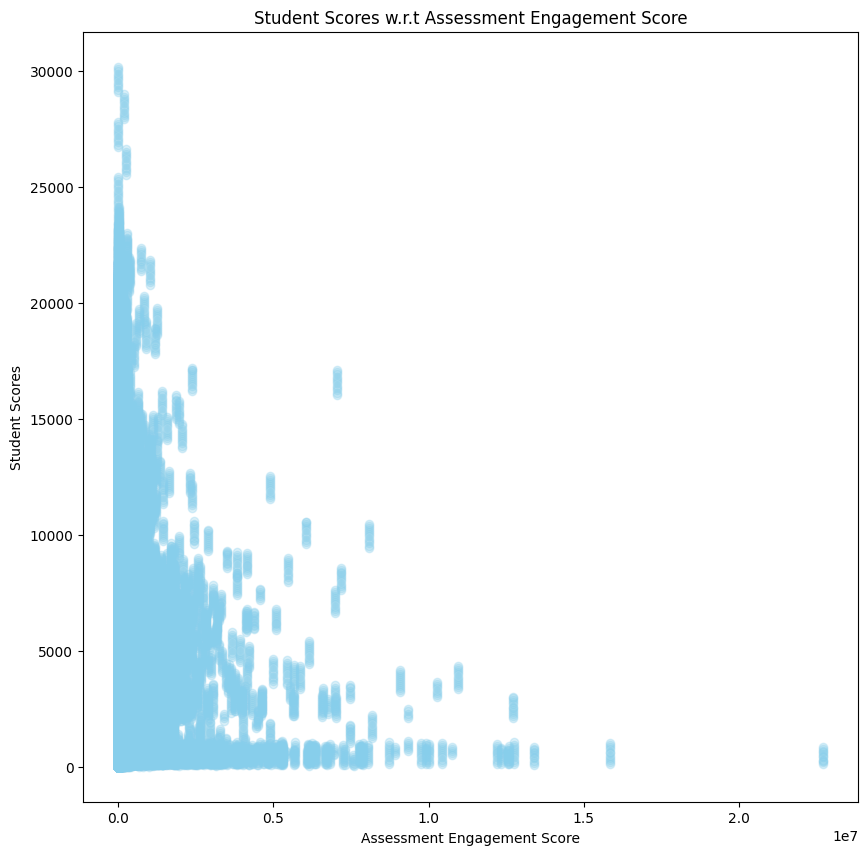

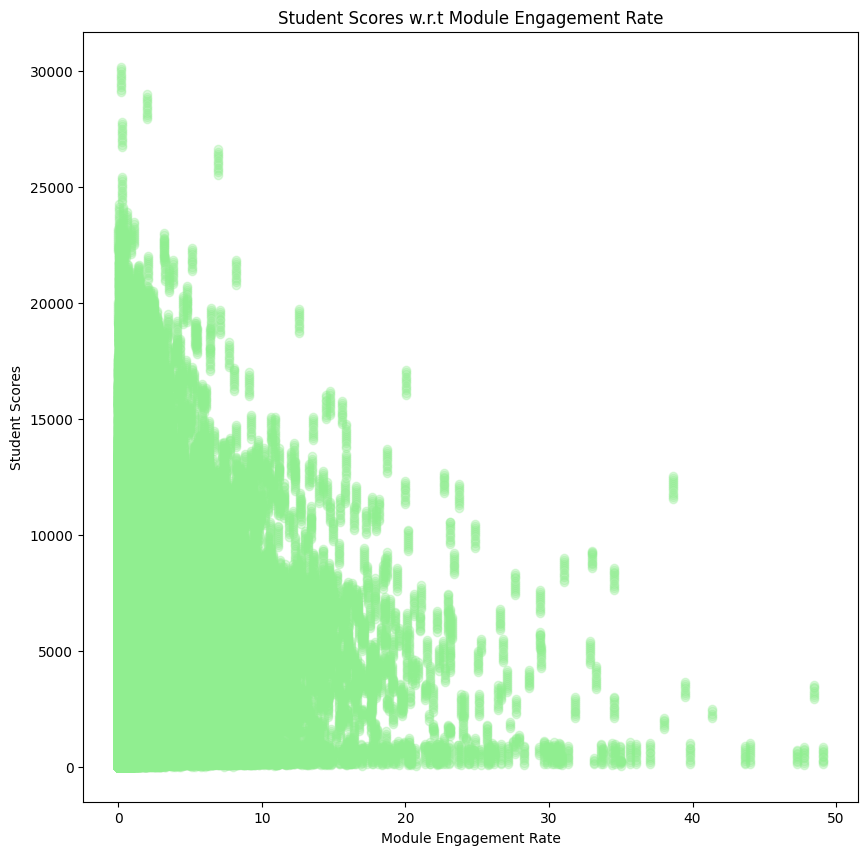

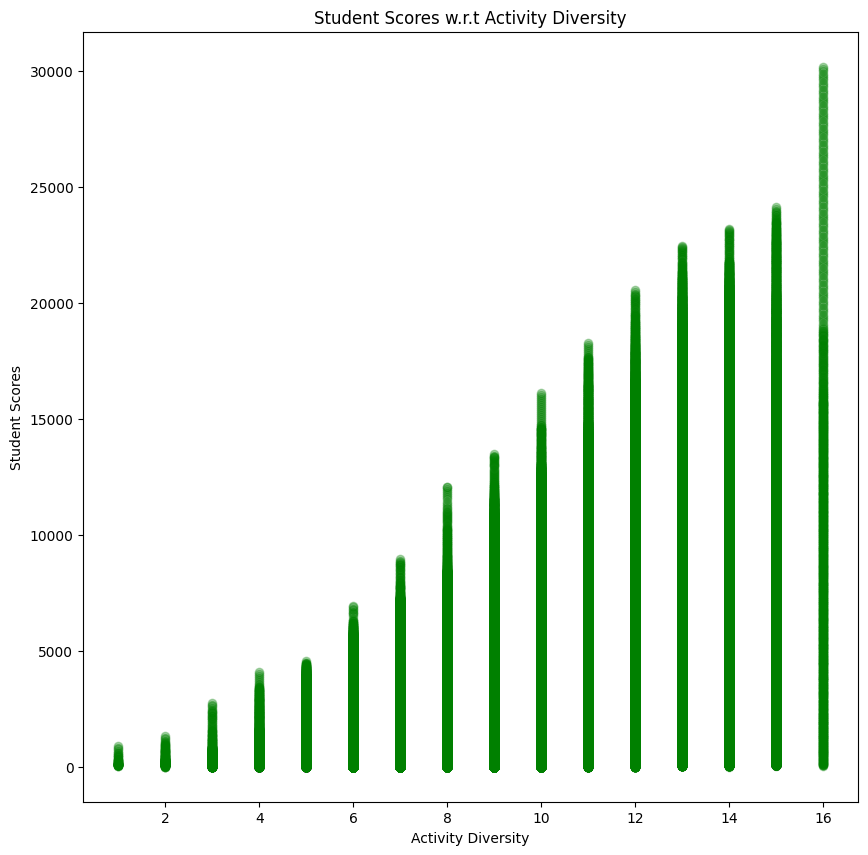

In [62]:
# Plot 1: Student Scores w.r.t Assessment Engagement Score
plt.figure(figsize=(10, 10))
plt.title('Student Scores w.r.t Assessment Engagement Score')
plt.xlabel("Assessment Engagement Score")
plt.ylabel("Student Scores")
plt.scatter(data=df_final, x='assessment_engagement_score', y='cumulative_score', alpha=.3, color="skyblue")
plt.show()

# Plot 2: Student Scores w.r.t Module Engagement Rate
plt.figure(figsize=(10, 10))
plt.title('Student Scores w.r.t Module Engagement Rate')
plt.xlabel("Module Engagement Rate")
plt.ylabel("Student Scores")
plt.scatter(data=df_final, x='module_engagement_rate', y='cumulative_score', alpha=.3, color="lightgreen")
plt.show()

# Plot 3: Student Scores w.r.t Activity Diversity
plt.figure(figsize=(10, 10))
plt.title('Student Scores w.r.t Activity Diversity')
plt.xlabel("Activity Diversity")
plt.ylabel("Student Scores")
plt.scatter(data=df_final, x='activity_diversity', y='cumulative_score', alpha=.3, color="green")
plt.show()


In [63]:

# Group by high and low VLE engagement based on median 'module_engagement_rate'
median_engagement = df_final['module_engagement_rate'].median()
df_final['engagement_group'] = df_final['module_engagement_rate'].apply(lambda x: 'High' if x >= median_engagement else 'Low')

# Group by high and low activity diversity based on median 'activity_diversity'
median_activity_diversity = df_final['activity_diversity'].median()
df_final['activity_diversity_group'] = df_final['activity_diversity'].apply(lambda x: 'High' if x >= median_activity_diversity else 'Low')

# Group by high and low assessment engagement based on median 'assessment_engagement_score'
median_assessment_engagement = df_final['assessment_engagement_score'].median()
df_final['assessment_engagement_group'] = df_final['assessment_engagement_score'].apply(lambda x: 'High' if x >= median_assessment_engagement else 'Low')

# T-test for VLE Engagement
high_engagement_grades = df_final[df_final['engagement_group'] == 'High']['cumulative_score']
low_engagement_grades = df_final[df_final['engagement_group'] == 'Low']['cumulative_score']
t_stat_engagement, p_value_engagement = ttest_ind(high_engagement_grades, low_engagement_grades, equal_var=False)

# T-test for Activity Diversity
high_activity_diversity_grades = df_final[df_final['activity_diversity_group'] == 'High']['cumulative_score']
low_activity_diversity_grades = df_final[df_final['activity_diversity_group'] == 'Low']['cumulative_score']
t_stat_activity_diversity, p_value_activity_diversity = ttest_ind(high_activity_diversity_grades, low_activity_diversity_grades, equal_var=False)

# T-test for Assessment Engagement
high_assessment_engagement_grades = df_final[df_final['assessment_engagement_group'] == 'High']['cumulative_score']
low_assessment_engagement_grades = df_final[df_final['assessment_engagement_group'] == 'Low']['cumulative_score']
t_stat_assessment_engagement, p_value_assessment_engagement = ttest_ind(high_assessment_engagement_grades, low_assessment_engagement_grades, equal_var=False)

# Output the results
print("\nHypothesis Testing Results:")
print(f"T-test  (Module Engagement Rate): {t_stat_engagement:.4f}, P-Value (VLE Engagement): {p_value_engagement:.4e}")
print(f"T-test (Activity Diversity): {t_stat_activity_diversity:.4f}, P-Value (Activity Diversity): {p_value_activity_diversity:.4e}")
print(f"T-test (Assessment Engagement): {t_stat_assessment_engagement:.4f}, P-Value (Assessment Engagement): {p_value_assessment_engagement:.4e}")



Hypothesis Testing Results:
T-test  (Module Engagement Rate): 12.7121, P-Value (VLE Engagement): 5.0842e-37
T-test (Activity Diversity): 643.7940, P-Value (Activity Diversity): 0.0000e+00
T-test (Assessment Engagement): 76.3764, P-Value (Assessment Engagement): 0.0000e+00


In [64]:
# Interpret the results
if p_value_engagement < 0.05:
    print("VLE engagement improves student grades.")
else:
    print("No significant impact of VLE engagement on student grades.")

if p_value_activity_diversity < 0.05:
    print("Activity diversity significantly impacts student grades.")
else:
    print("No significant impact of activity diversity on student grades.")

if p_value_assessment_engagement < 0.05:
    print("Assessment engagement significantly impacts student grades.")
else:
    print("No significant impact of assessment engagement on student grades.")


VLE engagement improves student grades.
Activity diversity significantly impacts student grades.
Assessment engagement significantly impacts student grades.


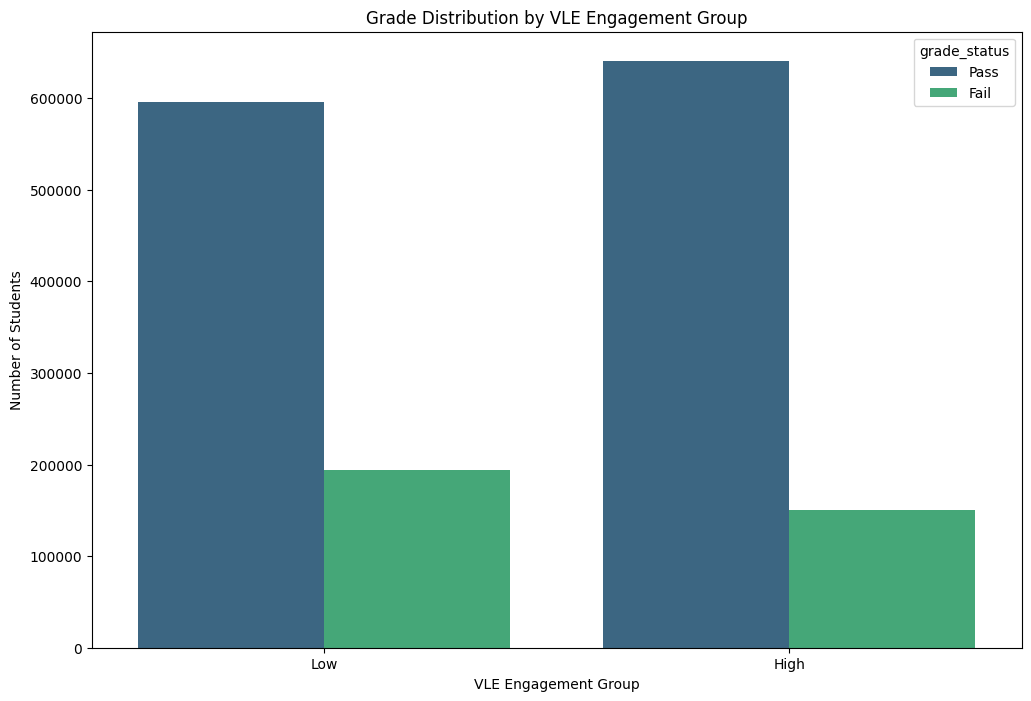

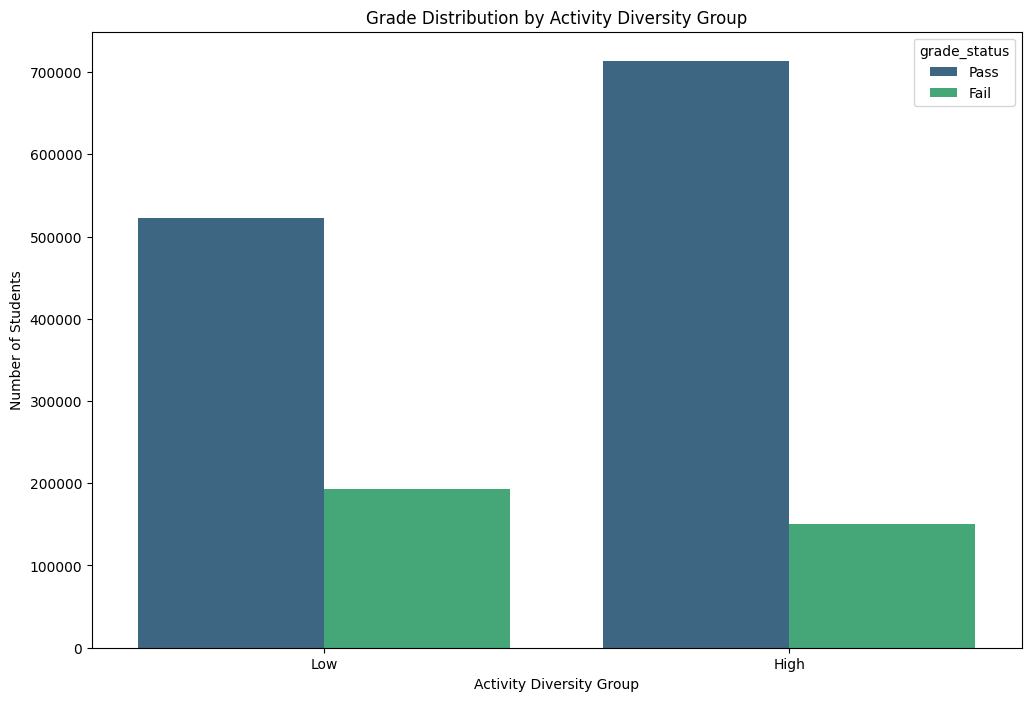

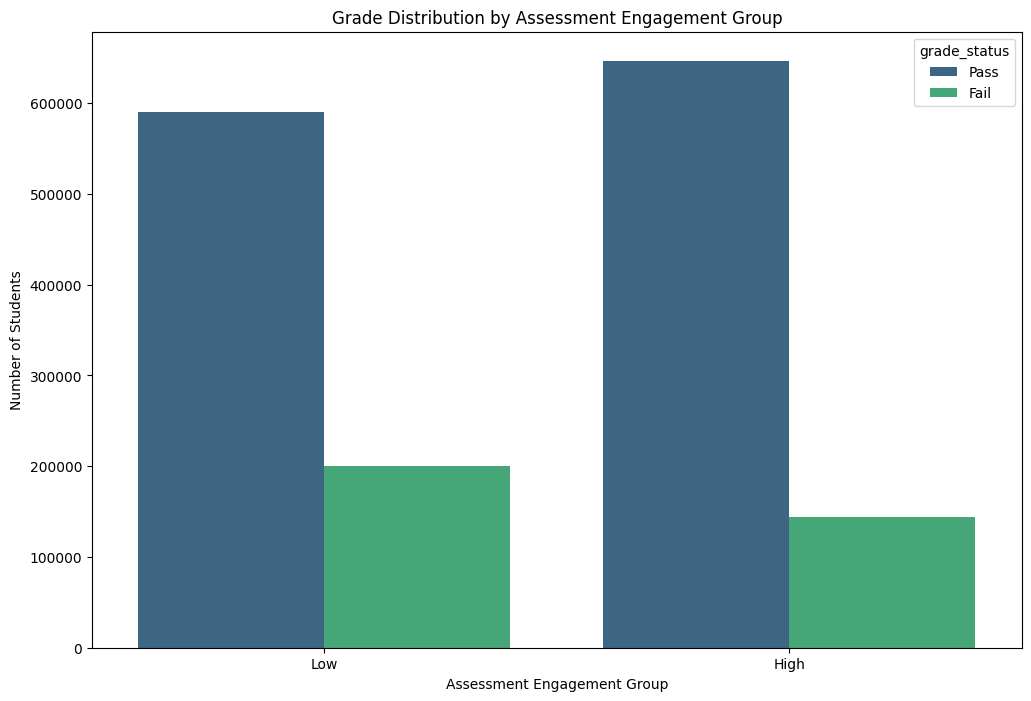

In [72]:
# If grade_status doesn't exist, create it from final_result
if 'grade_status' not in df_final.columns:
    df_final['grade_status'] = df_final['final_result'].apply(lambda x: 'Pass' if x in ['Pass', 'Distinction'] else 'Fail')

# Visualization: Grade Distribution by VLE Engagement Group
plt.figure(figsize=(12, 8))
sns.countplot(data=df_final, x='engagement_group', hue='grade_status', palette="viridis")
plt.title("Grade Distribution by VLE Engagement Group")
plt.xlabel("VLE Engagement Group")
plt.ylabel("Number of Students")
plt.show()

# Visualization: Grade Distribution by Activity Diversity Group
plt.figure(figsize=(12, 8))
sns.countplot(data=df_final, x='activity_diversity_group', hue='grade_status', palette="viridis")
plt.title("Grade Distribution by Activity Diversity Group")
plt.xlabel("Activity Diversity Group")
plt.ylabel("Number of Students")
plt.show()

# Visualization: Grade Distribution by Assessment Engagement Group
plt.figure(figsize=(12, 8))
sns.countplot(data=df_final, x='assessment_engagement_group', hue='grade_status', palette="viridis")
plt.title("Grade Distribution by Assessment Engagement Group")
plt.xlabel("Assessment Engagement Group")
plt.ylabel("Number of Students")
plt.show()


In [73]:
# Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model_data = df_final[[
    'code_module', 'code_presentation', 'gender', 'region', 'highest_education',
    'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability',
    'date_registration', 'final_result', 'assessment_engagement_score', 'module_engagement_rate', 'activity_diversity'
]]

# Encode target variable and preprocess categorical features
model_data['final_result'] = model_data['final_result'].map({'Pass': 1, 'Distinction': 2, 'Fail': 0, 'Withdrawn': -1})
model_data.gender = model_data.gender.map({'M': 1, 'F': 0})
model_data.disability = model_data.disability.map({'Y': 1, 'N': 0})
model_data = pd.get_dummies(model_data, columns=[
    'code_module', 'code_presentation', 'region',
    'highest_education', 'imd_band', 'age_band'
])


# Split data into training and testing sets
X = model_data.drop(columns=['final_result'])
y = model_data['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# GridSearch for the best hyperparameters
param_grid = {
    'criterion': ['gini'], # Use only one criterion
    'max_depth': [10, 20],  # Use fewer options for max_depth
    'min_samples_split': [2, 5],  # Reduce options for min_samples_split
    'min_samples_leaf': [1, 2]  # Reduce options for min_samples_leaf
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Train Decision Tree Classifier with the best parameters
best_tree = grid_search.best_estimator_
best_tree.fit(X_train, y_train)

# Evaluate the model
y_pred = best_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

<ipython-input-73-d685c1759fc0>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['final_result'] = model_data['final_result'].map({'Pass': 1, 'Distinction': 2, 'Fail': 0, 'Withdrawn': -1})
<ipython-input-73-d685c1759fc0>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data.gender = model_data.gender.map({'M': 1, 'F': 0})
<ipython-input-73-d685c1759fc0>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.82

Classification Report:
               precision    recall  f1-score   support

          -1       0.85      0.50      0.63     32491
           0       0.81      0.61      0.69     70698
           1       0.82      0.95      0.88    295830
           2       0.86      0.67      0.76     74989

    accuracy                           0.82    474008
   macro avg       0.83      0.68      0.74    474008
weighted avg       0.83      0.82      0.82    474008



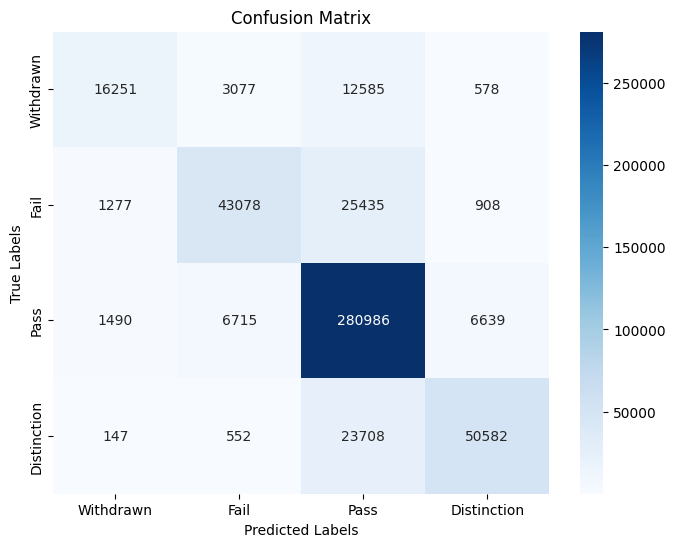

In [74]:
# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Withdrawn', 'Fail', 'Pass', 'Distinction'], yticklabels=['Withdrawn', 'Fail', 'Pass', 'Distinction'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()